In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.special import expit
from scipy.stats import logistic
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
from astropy.coordinates import SkyCoord 
from astropy import units as u
import statsmodels.api as sm
import logistic_fit as logfit

In [2]:
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
predicted_sigma_idx = 8
output_sigma_idx = 10

data = np.unique(np.loadtxt('./injections/homogeneous_injections.txt'), axis = 0)
print(len(data))

44835


Apply TONS of masks to pick only a very small range of data and see how many injections we have post-masking:

In [3]:
days = np.unique(data[:, 2])
p_total = []
RFI_mask = (data[:, S_idx] < 1e-1) & (data[:, -1] > 0)
fglob_mask = (data[:, f_idx] > 0.1) & (data[:, f_idx] < 250.)
DMglob_mask = (data[:, DM_idx] > 1.) & (data[:, DM_idx] < 400.)
DM_good_mask = (np.abs(data[:, 5] - data[:, -1]) <= 1.) | (data[:, -1] < 0)
FWHMglob_mask = (data[:, FWHM_idx] > 0.006) & (data[:, FWHM_idx] < 0.046)
glob_mask = fglob_mask & DMglob_mask & FWHMglob_mask & DM_good_mask 
data_glob = data[glob_mask & ~RFI_mask]

for i in range(len(days)):
    day_mask = data_glob[:, 2] == days[i]
    success_mask = data_glob[:, -1] > 0.
    p = len(data_glob[day_mask & success_mask]) / len(data_glob[day_mask])
    print(f'{int(days[i])}-day stack: {len(data_glob[day_mask])} injections, p({int(days[i])}) = {p:.2f}')
    p_total.append(p)

1-day stack: 1757 injections, p(1) = 0.30
4-day stack: 1593 injections, p(4) = 0.37
7-day stack: 1782 injections, p(7) = 0.36
10-day stack: 1733 injections, p(10) = 0.36
13-day stack: 1684 injections, p(13) = 0.39
16-day stack: 1635 injections, p(16) = 0.37
19-day stack: 1585 injections, p(19) = 0.39
22-day stack: 1399 injections, p(22) = 0.40
25-day stack: 1477 injections, p(25) = 0.40
28-day stack: 1278 injections, p(28) = 0.41
31-day stack: 1161 injections, p(31) = 0.39
34-day stack: 1156 injections, p(34) = 0.39
37-day stack: 1089 injections, p(37) = 0.42
40-day stack: 1020 injections, p(40) = 0.38
43-day stack: 848 injections, p(43) = 0.40
46-day stack: 803 injections, p(46) = 0.40
49-day stack: 557 injections, p(49) = 0.39
52-day stack: 307 injections, p(52) = 0.40
55-day stack: 199 injections, p(55) = 0.45
58-day stack: 12 injections, p(58) = 0.58
61-day stack: 9 injections, p(61) = 0.44


Crucial function below! `get_cross_point()` fits a sigmoid "turn-on" curve to a series of booleans. 

In [4]:
def get_cross_point(x, y, logspace = True, bootstrap = False, n_boot = 10000,):
    """
    This function HYPOTHETICALLY fits a sigmoid curve to a "turn-on" distribution.
    For the flux turn-on, we need it to fit in logS scale.
    For the days turn-on we need it to fit in linear scale.

    There are two options for how to estimate mean and errors of the crossing point. 
    The default is to draw random samples from the fit curve and take the mean and std.
    This is fast but not super accurate. The other option is to use bootstrapping, which takes
    ~100x as long but is way more accurate.

    Inputs:
    ------
        x (arr)         : the independent variable; in this case either flux density or number of days
        y (arr)         : array of booleans representing detection; can be in either bool or float format
        logspace (bool) : evaluate independent variable in logspace instead of linear
        bootstrap (bool): evaluate mean and standard deviation using bootstrapping for higher accuracy
        n_boot (float)  : number of bootstrapping iterations 

    Returns:
    --------
        x0_fit (float): crossing point of fitted sigmoid curve, aka 50% probability of detection
        x0_err (float): standard deviation of crossing point -- pick method for accuracy needed
        cdf_fit (func): function to evaluate fitted sigmoid curve (useful for plotting)

    """

    #make sure that x and y are in 0/1 format even if sent in as booleans
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
 
    #allow for either log-spaced or linear-spaced fitting; default is log
    argx = np.log(x) if logspace else x

    if bootstrap:

        b_boot = np.zeros((n_boot, 2)) 
        
        for i in range(n_boot):
            idx = np.random.choice(len(argx), size=len(argx), replace=True)
            argx_boot, y_boot = argx[idx], y[idx]
            
            #allow the crosspoint to occur somewhere other than 0
            X_boot = sm.add_constant(argx_boot)
            #fit the model
            model_boot = sm.Logit(y_boot, X_boot).fit(disp=False)
            
            b_boot[i] = model_boot.params

        b = b_boot

    else:
        
        X = sm.add_constant(argx)
        #fit the model
        model = sm.Logit(y, X)
        model.fit()
        cdf_fit = model.cdf
        #model.summary()
    
        #generate random samples from model
        b = np.random.multivariate_normal(model.params,
                                                        model.cov_params(),
                                                        size=10000)

    # - intercept / slope
    argx0_samples = -b[:, 0] / b[:, 1]
    
    #allow for either log or linear spacing
    x0_samples = np.exp(argx0_samples) if logspace else argx0_samples

    x0_fit = x0_samples.mean()
    x0_err = x0_samples.std()

    x0_err = np.sqrt(np.diag(model.cov_params()))[0]

    print(f"S at P=0.5: {x0_fit:.4f} ± {x0_err:.4f}")

    #create a function from the fit
    b0, b1 = np.mean(b, axis = 0)
 
    # def cdf_fit(s):
    #     s = np.asarray(s, dtype=float)
    #     arg_s = np.log(s) if logspace else s
    #     return 1 / (1 + np.exp(-(b0 + b1 * arg_s)))

    return x0_fit, x0_err, cdf_fit

def get_cross_point_via_density(S, y, S_bins, S_dev):

    print(np.column_stack((S, y)).shape)
    _, _, trans_smooth_S = au.get_sensitivity(
    np.column_stack((S, y)),
    *(0, S_bins, S_dev),
    stype = '1d',
    )

    cross_idx = np.where(trans_smooth_S >= 0.5)[0][0]
    return S[cross_idx]

def get_cross_point_2(X, y, logspace = True):
    
    #make sure that X and y are in 0/1 format even if sent in as booleans
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
 
    #allow for either log-spaced or linear-spaced fitting; default is log
    argX = np.log(X) if logspace else X
    exog = sm.add_constant(argX)
 
    model = sm.Logit(y, exog)
    result = model.fit(disp=0) #disp=0 silences the output
 
    b0, b1 = result.params
    cov = result.cov_params()  
    intercept = np.exp(-b0 / b1) if logspace else -b0 / b1

    #du/db0 = -1/b1, du/db1 = b0/b1^2. i think this is right?
    var_intercept = (cov[0, 0] / b1**2
             - 2 * b0 * cov[0, 1] / b1**3
             + b0**2 * cov[1, 1] / b1**4)
    se_intercept = np.sqrt(var_intercept)

    if logspace:
        cdf_fit = lambda x: model.cdf(b0 + b1 * np.log(x)) 
    else:
        cdf_fit = lambda x: model.cdf(b0 + b1 * x) 

    print(f'S = {intercept:.2f} +/- {se_intercept:.4f}')

    return intercept, se_intercept, cdf_fit

In [9]:
def add_subplot_data(ax, S, y):
    
    ax.plot(S, y,
               '.', 
               color = 'black', 
               alpha = 0.1)
    
    ax.set_xscale('log')
    ax.set_ylim(-0.1, 1.1)

def add_subplot_fit(ax, S, S_cross, cdf_fit):

    x = np.linspace(np.min(S), np.max(S), 1000)

    ax.plot(x, 
        cdf_fit(x),
        'r--'
        )
    
    ax.vlines(S_cross,
                 ymin = -0.1,
                 ymax = 1.1,
                 color = 'black'
                 )
    
    ax.plot(-1, -1, 'r--', label = 'Logistic Fit')
    ax.vlines(-1, 0.1, 0.2, color = 'black', label = 'Crosspoint')


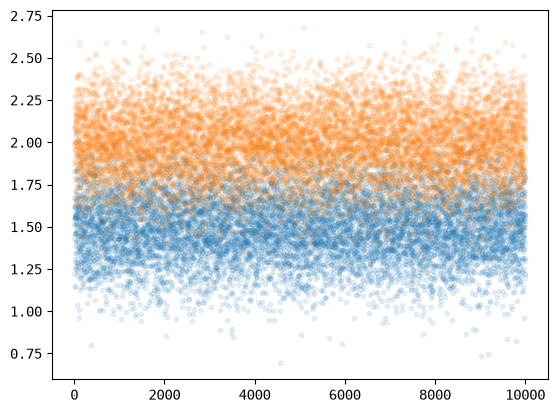

In [10]:
params = [1.5, 2]
cov_params = [[0.04, 0.03], [0.03, 0.04]]
random_draw = np.random.multivariate_normal(params, cov_params, size=10000)

plt.plot(random_draw, '.', alpha = 0.1)
# X = sm.add_constant(argx)
# #fit the model
# model = sm.Logit(y, X).fit()
# model.summary()
    

In [11]:
S_hot = np.zeros(len(days))
S_cold = np.zeros(len(days))
S_hot_err = np.zeros(len(days))
S_cold_err = np.zeros(len(days))

S_bins = np.logspace(-2, 1, 250)
S_dev = 100

fig, ax = plt.subplots(len(days), 2, figsize = (10, 40))

for i in range(len(days)):

    #grab data only for the specific day we're evaluating
    day_mask = data_glob[:, 2] == days[i]
    datum = data_glob[day_mask]

    #separate coords into on- and off-plane groups
    coords = SkyCoord(ra=datum[:, 0]*u.deg, dec=datum[:, 1]*u.deg, frame='icrs')
    galactic_lat = coords.galactic.b
    low_b_mask = np.abs(galactic_lat) < 10*u.degree
    high_b_mask = np.abs(galactic_lat) > 10*u.degree 
    
    print(f'Hot {days[i]}-day stack: {len(datum[low_b_mask])} samples.')
    print(f'Cold {days[i]}-day stack: {len(datum[high_b_mask])} samples.')

    S = datum[:, S_idx] 
    y = (datum[:, -1] > 0.).astype(int)
    
    if len(datum[low_b_mask]) > 200:
        
        S_hot[i], S_hot_err[i], cdf_fit = logfit.get_cross_point(S[low_b_mask], 
                                                                 y[low_b_mask]) 

        add_subplot_fit(ax[i, 0], S[low_b_mask], S_hot[i], cdf_fit)
    
    else: 
        S_hot[i] = np.nan
        S_hot_err[i] = np.nan
    
    if len(datum[high_b_mask]) > 200:

        S_cold[i], S_cold_err[i], cdf_fit = get_cross_point_2(S[high_b_mask], y[high_b_mask])
        
        add_subplot_fit(ax[i, 1], S[high_b_mask], S_cold[i], cdf_fit)

    else:
        S_cold[i] = np.nan
        S_cold_err[i] = np.nan

    try:
        add_subplot_data(ax[i, 0], S[low_b_mask], y[low_b_mask]) #data for hot sky
        add_subplot_data(ax[i, 1], S[high_b_mask], y[high_b_mask]) #data for cold sky
    except:
        continue
    
    ax[i, 0].set_title(f'N = {int(days[i])} d hot sky')
    ax[i, 1].set_title(f'N = {int(days[i])} d cold sky')
    ax[i, 0].set_xlabel('S (mJy)')
    ax[i, 1].set_xlabel('S (mJy)')
    ax[i, 0].set_ylabel('Detected?')

# fig.legend()
plt.tight_layout()
plt.savefig('Flux_Fits.pdf')
plt.close()

Hot 1.0-day stack: 594 samples.
Cold 1.0-day stack: 1163 samples.
S = 0.85 +/- 0.0737
S = 0.50 +/- 0.0563
Hot 4.0-day stack: 518 samples.
Cold 4.0-day stack: 1075 samples.
S = 0.49 +/- 0.0810
S = 0.31 +/- 0.0570
Hot 7.0-day stack: 619 samples.
Cold 7.0-day stack: 1163 samples.
S = 0.41 +/- 0.0837
S = 0.26 +/- 0.0608
Hot 10.0-day stack: 606 samples.
Cold 10.0-day stack: 1127 samples.
S = 0.41 +/- 0.0781
S = 0.27 +/- 0.0605
Hot 13.0-day stack: 578 samples.
Cold 13.0-day stack: 1106 samples.
S = 0.34 +/- 0.0856
S = 0.24 +/- 0.0647
Hot 16.0-day stack: 544 samples.
Cold 16.0-day stack: 1091 samples.
S = 0.37 +/- 0.0985
S = 0.22 +/- 0.0572
Hot 19.0-day stack: 530 samples.
Cold 19.0-day stack: 1055 samples.
S = 0.32 +/- 0.0948
S = 0.22 +/- 0.0560
Hot 22.0-day stack: 458 samples.
Cold 22.0-day stack: 941 samples.
S = 0.35 +/- 0.1107
S = 0.22 +/- 0.0656
Hot 25.0-day stack: 481 samples.
Cold 25.0-day stack: 996 samples.
S = 0.29 +/- 0.1055
S = 0.20 +/- 0.0602
Hot 28.0-day stack: 483 samples.
Col

In [40]:
import logistic_fit as logfit
import importlib
importlib.reload(logfit)

<module 'logistic_fit' from '/data1/people/rsquillace/Transmissivity/results/logistic_fit.py'>

S = 4.99 +/- 0.0899
Cross point:
True: 5.00 --> Fit: 4.99 +/- 0.09
Slope: True: 5.00 --> Fit: 9.42 +/- 0.91


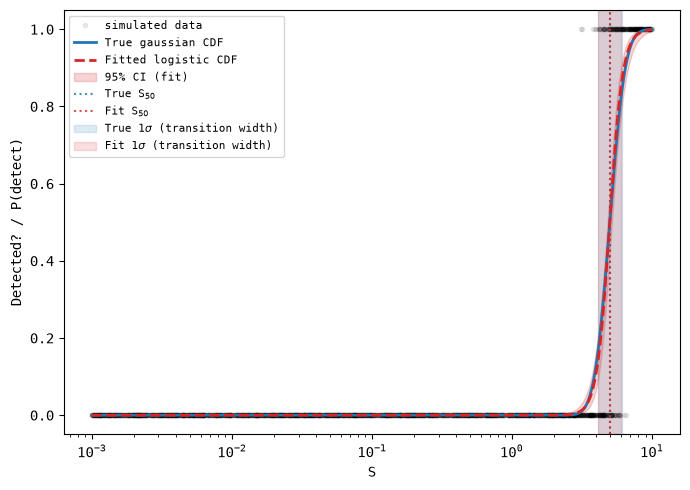

--- true = gaussian, fit = logistic ---
True/Fit cross point: mean = 1.001, std = 0.037
True/Fit slope: mean = 0.533, std = 0.090
True/Fit standard deviation: mean = 1.069, std = 0.226


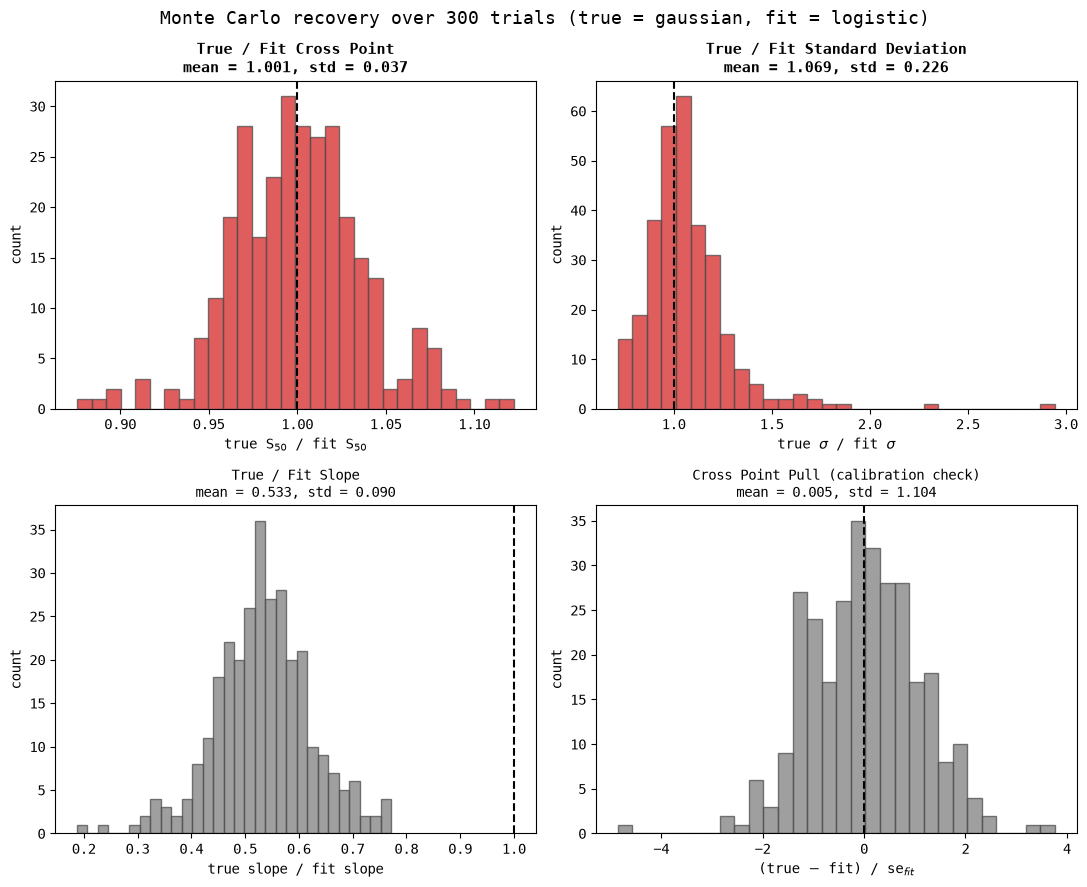

--- true = gaussian, fit = logistic ---
True/Fit cross point: mean = 1.001, std = 0.037
True/Fit slope: mean = 0.533, std = 0.090
True/Fit standard deviation: mean = 1.069, std = 0.226


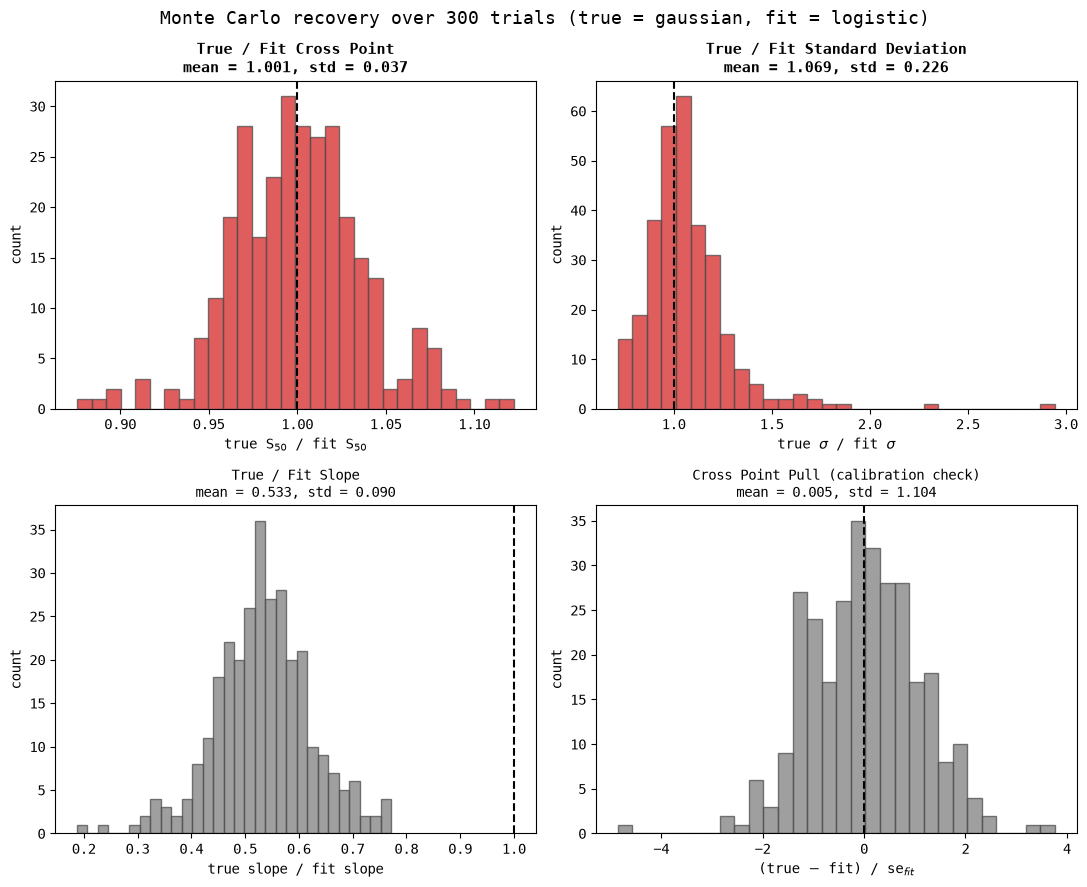

--- true = logistic, fit = logistic ---
True/Fit cross point: mean = 0.998, std = 0.047
True/Fit slope: mean = 0.971, std = 0.133
True/Fit standard deviation: mean = 1.051, std = 0.157
--- true = gaussian, fit = logistic ---
True/Fit cross point: mean = 1.001, std = 0.037
True/Fit slope: mean = 0.533, std = 0.090
True/Fit standard deviation: mean = 1.069, std = 0.226
--- true = logistic, fit = gaussian ---
True/Fit cross point: mean = 0.999, std = 0.048
True/Fit slope: mean = 1.779, std = 0.248
True/Fit standard deviation: mean = 1.040, std = 0.155
--- true = gaussian, fit = gaussian ---
True/Fit cross point: mean = 1.001, std = 0.037
True/Fit slope: mean = 0.962, std = 0.161
True/Fit standard deviation: mean = 1.075, std = 0.232


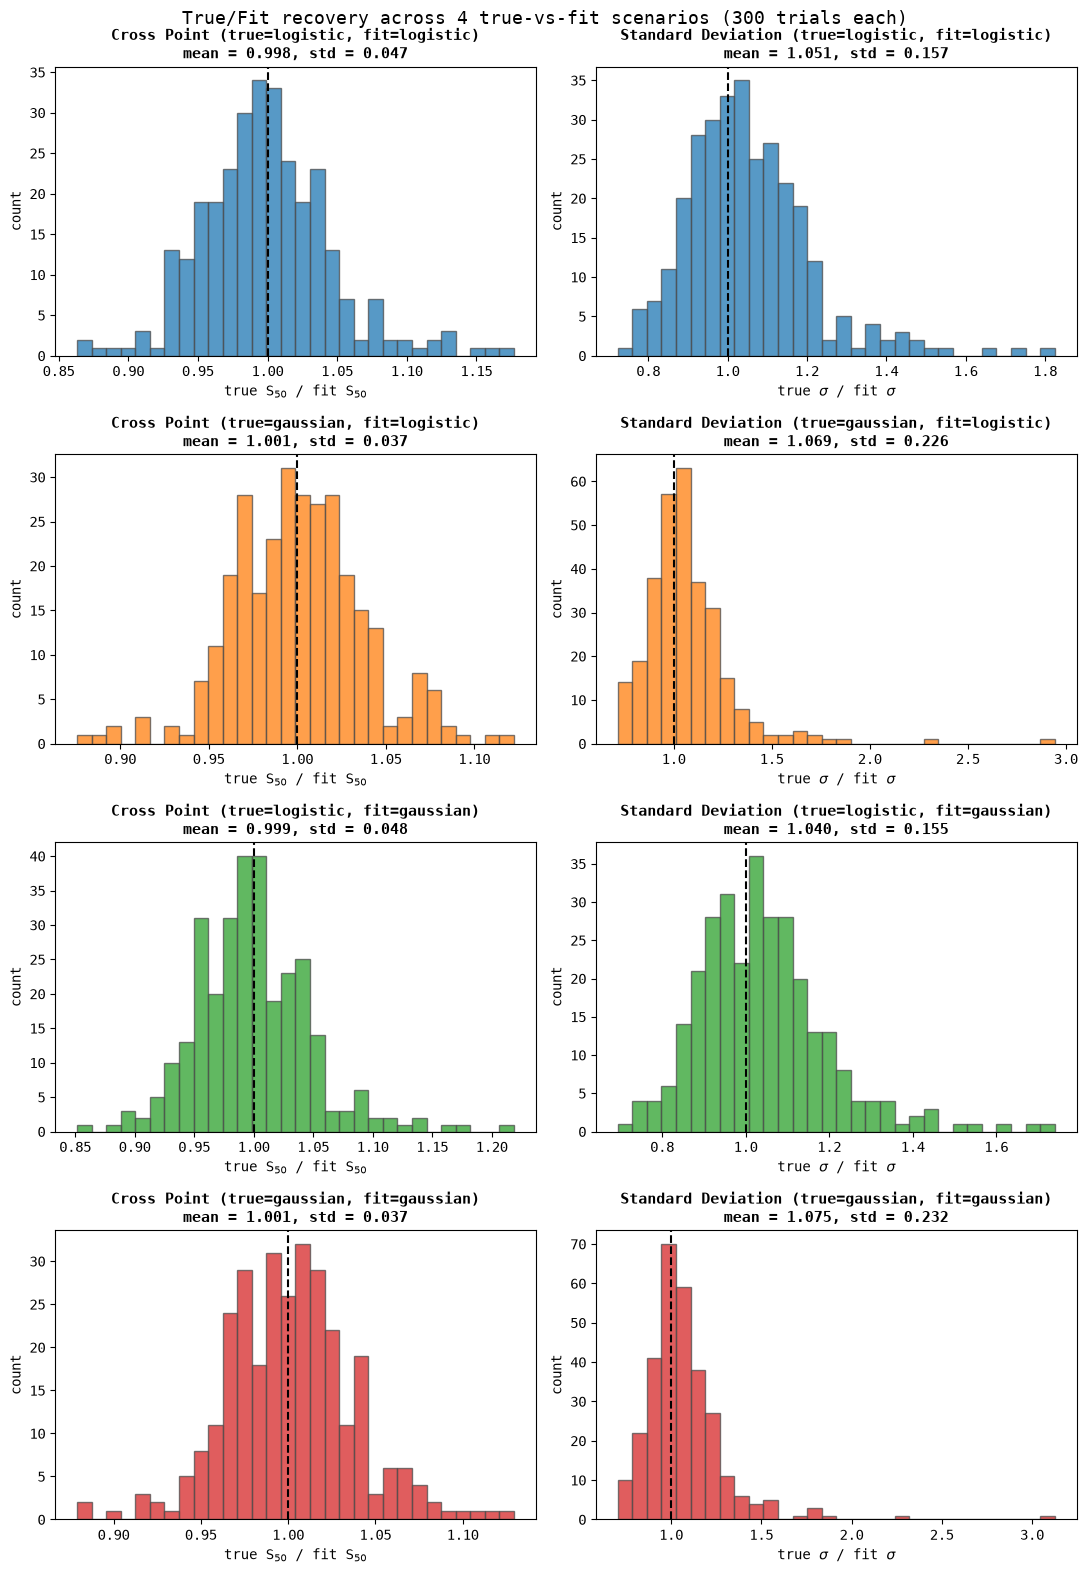

In [47]:
logfit.run_test(plot = True)
logfit.run_monte_carlo(plot = True)
logfit.run_monte_carlo(plot = True, fit_family = 'logistic')
results = logfit.compare_families(N=300, plot=True)


You can now check out `Flux_Fits.pdf` to see diagnostic plots for these fits.

Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

where $\delta$ is the effective width.

Assuming that we will find >50% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [48]:
GAIN = 1.16e-3  # K mJy^-1
TSYS = 50  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
F_NYQUIST = 508 #Hz
BANDWIDTH = 400e6 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_dedispersion_time():

    #max DM offset we can have for channelization of 0.1 pcc
    delta_DM = 0.05 #pc / cm^-3 
    
    dt = DM_CONSTANT * delta_DM * (1/FREQ_BOTTOM**2 - 1/FREQ_TOP**2)
    
    return dt

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft

def get_intrachannel_time(DM, maxDM):
        
    nchan = get_nchans(maxDM)

    quadratic_terms = {
            "1024": 1e-8,
            "2048": 6e-9,
            "4096": 3e-9,
            "8192": 1.5e-9,
            "16384": 8e-10,
        }
    quadratic_term = quadratic_terms[str(nchan)]

    t_intrachannel = DM * DM_CONSTANT * quadratic_term
    
    return t_intrachannel

def radiometer(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    FWHM /= f #in s
    tau = Ndays * 10 * 60 #days x minutes / day x seconds / minute
 
    t_dedisp = get_dedispersion_time() #in s
    t_intrach = get_intrachannel_time(DM, maxDM)
    
    FWHM = np.sqrt(FWHM**2 + t_dedisp**2 )
    FWHM = np.sqrt(FWHM**2 + t_intrach**2)
    FWHM = np.sqrt(FWHM**2 + TSAMP**2)

    system_terms =  BETA * (TSYS + Tsky) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * (BANDWIDTH / 2)) #for rfi...
    pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM)) 

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM, Tsky, Ndays)
            Smin[k, l] = S_temp

    return Smin


In [49]:
def power_law(x, A, alpha):

    return A * x**alpha

# par_hot = curve_fit(power_law, days, S_hot, p0 = (1, -0.5))
# par_cold = curve_fit(power_law, days, S_cold, p0 = (1, -0.5))

# print(f'alpha_hot = {par_hot[0][1]:.2f}')
# print(f'alpha_cold = {par_cold[0][1]:.2f}')

In [50]:
many_days = np.linspace(0.2, 58)
Smin_hot_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_hot_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_cold_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 
Smin_cold_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 

(0.017453642746568607, 13.121371734219267)

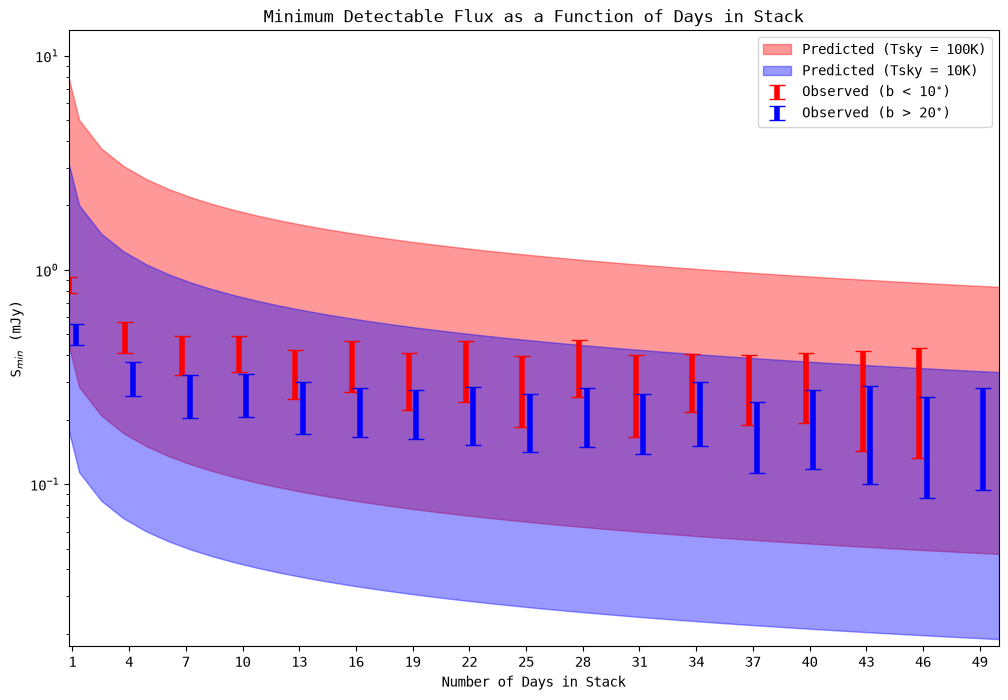

In [61]:

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
ymax = max(Smin_hot_fast)

mask_hot = np.isfinite(Smin_hot_fast)
mask_cold = np.isfinite(Smin_cold_fast)

upper_hot = np.where(mask_hot, Smin_hot_fast, ymax)
upper_cold = np.where(mask_cold, Smin_cold_fast, ymax)

hot_nanmask = np.isnan(S_hot) 
cold_nanmask = np.isnan(S_cold)

ax.fill_between(many_days, Smin_hot_mid, Smin_hot_fast,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(many_days, Smin_cold_mid, Smin_cold_fast,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')
ax.errorbar(days[~hot_nanmask] - 0.2, S_hot[~hot_nanmask], yerr=S_hot_err[~hot_nanmask],
            color='r', marker=None, linestyle='none', linewidth=4., capsize=6,
            label=r'Observed (b < 10$^{\circ}$)')
ax.errorbar(days[~cold_nanmask] + 0.2, S_cold[~cold_nanmask], yerr=S_cold_err[~cold_nanmask],
            color='b', marker=None, linestyle='none', linewidth=4., capsize=6,
            label=r'Observed (b > 20$^{\circ}$)')


ax.legend()
ax.set_xticks(range(1, 52, 3))
ax.set_xlabel('Number of Days in Stack')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.set_yscale('log')
ax.set_title('Minimum Detectable Flux as a Function of Days in Stack')
ax.set_xlim(0.8, 50)
ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

In [ ]:
import test_logistic_fit as test

In [ ]:
sim_S, sim_y, _ = test.get_simulated_data()
cross_sim, se_sim, cdf_fit_sim = get_cross_point_2(sim_S, sim_y)

S = 2.03 +/- 0.0265


Now we'll plot in period space:

In [ ]:
#all_data = np.concatenate(data, axis = 0)
period_mask = DMglob_mask & FWHMglob_mask & DM_good_mask & ~RFI_mask
coords = SkyCoord(ra=data[:, 0]*u.deg, dec=data[:, 1]*u.deg, frame='icrs')
galactic_lat = coords.galactic.b
low_b_mask = np.abs(galactic_lat) < 5*u.degree
high_b_mask = np.abs(galactic_lat) > 10*u.degree 

f_bins = np.logspace(np.log10(0.05), np.log10(250), 500)
f_dev = 50
S_bins = np.logspace(-2, 1, 500)
S_dev = 50

Smin_of_f = np.zeros((4, len(f_bins) - 1))
length_mask = data[:, 2] == 28 #pick number of days

print(f'Analyzing {len(data[period_mask & length_mask & low_b_mask])} low-b injections.')
print(f'Analyzing {len(data[period_mask & length_mask & high_b_mask])} high-b injections.')

'''
_____________________
HOT SKY
'''
_, f_S_unsmooth_hot, f_S_smooth_hot = au.get_sensitivity(
    data[period_mask & low_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[0, j] = np.min(S_bins[np.where(f_S_smooth_hot[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

'''
_____________________
COLD SKY
'''
_, f_S_unsmooth_cold, f_S_smooth_cold = au.get_sensitivity(
    data[period_mask & high_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[1, j] = np.min(S_bins[np.where(f_S_smooth_cold[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

Smin_of_f[0] = gaussian_filter(Smin_of_f[0], 5)
Smin_of_f[1] = gaussian_filter(Smin_of_f[1], 5)


predicted_Smin_of_f = np.zeros((4, len(f_bins) - 1))
#shape is:
#hot sky, max DM 
#cold sky, max DM 
#hot sky, min DM 
#cold sky, min DM
predicted_Smin_of_f[0] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[1] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)
predicted_Smin_of_f[2] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[3] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)

Analyzing 335 low-b injections.
Analyzing 1013 high-b injections.


/tmp/ipykernel_2359741/215501640.py:78: RuntimeWarning: invalid value encountered in sqrt
  pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM))


Text(0.5, 1.0, 'Minimum Detectable Flux for 1-Month Stacks')

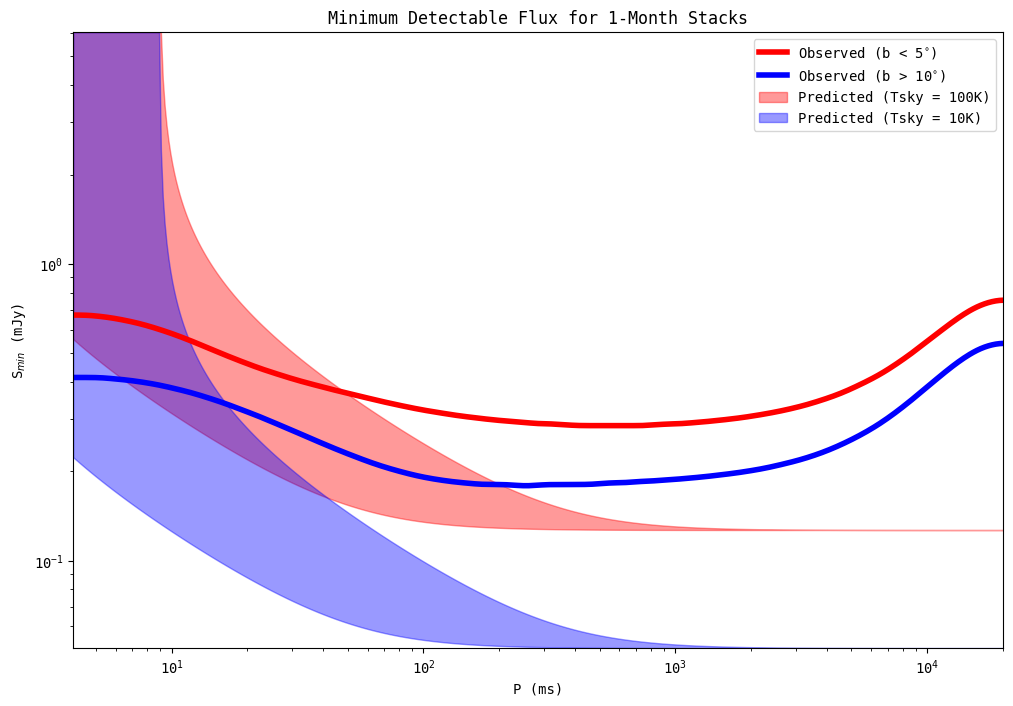

In [ ]:
P = 1/f_bins[:-1]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.plot(P*1e3, Smin_of_f[0], 'r', linewidth=4.0, label=r'Observed (b < 5$^{\circ}$)')
ax.plot(P*1e3, Smin_of_f[1], 'b', linewidth=4.0, label=r'Observed (b > 10$^{\circ}$)')

ax.loglog()
ymax = max(predicted_Smin_of_f[0])

mask_hot = np.isfinite(predicted_Smin_of_f[0])
mask_cold = np.isfinite(predicted_Smin_of_f[1])

upper_hot = np.where(mask_hot, predicted_Smin_of_f[0], ymax)
upper_cold = np.where(mask_cold, predicted_Smin_of_f[1], ymax)

ax.fill_between(P*1e3, predicted_Smin_of_f[2], upper_hot,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(P*1e3, predicted_Smin_of_f[3], upper_cold,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')

ax.set_xlabel('P (ms)')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.legend()
ax.set_xlim(min(P*1e3), max(P*1e3))
ax.set_ylim(min(predicted_Smin_of_f[3]), max(predicted_Smin_of_f[0]))
ax.set_title('Minimum Detectable Flux for 1-Month Stacks')

Below are crucial dignostics... not scientifically interesting, but keeping them here for reference.

1. All our stacks have the same coordinate distribution. We are not biasing different Ndays by picking different coordinate sets.

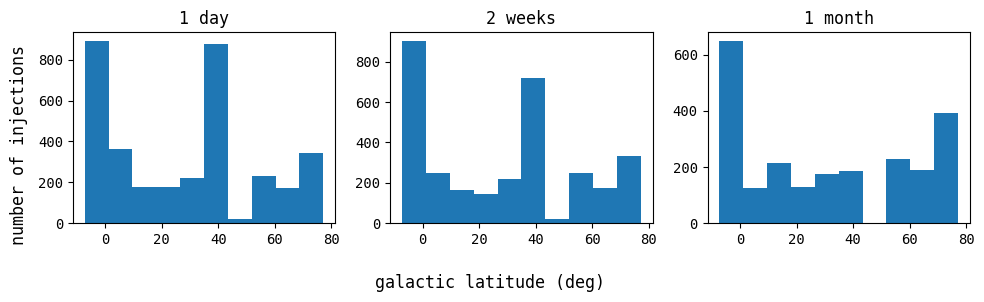

In [ ]:
mask_1 = data[:, 2] == 1.
coords = SkyCoord(ra=data[mask_1, 0]*u.deg, dec=data[mask_1, 1]*u.deg, frame='icrs')
b_1= coords.galactic.b

mask_16 = data[:, 2] == 16.
coords = SkyCoord(ra=data[mask_16, 0]*u.deg, dec=data[mask_16, 1]*u.deg, frame='icrs')
b_16 = coords.galactic.b

mask_31 = data[:, 2] ==  31.
coords = SkyCoord(ra=data[mask_31, 0]*u.deg, dec=data[mask_31, 1]*u.deg, frame='icrs')
b_31 = coords.galactic.b

counts_1, bins_1 = np.histogram(b_1)
counts_16, bins_16 = np.histogram(b_16)
counts_31, bins_31 = np.histogram(b_31)

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_16[:-1], bins_16, weights=counts_16)
ax[2].hist(bins_31[:-1], bins_31, weights=counts_31)

fig.supxlabel('galactic latitude (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

2. Injections with identical parameters injected into stacks of varying depth follow a retrieval sigma increase $\propto \sqrt{N}$.

In [ ]:
def func_to_fit(x, a, B):

    return a * np.sqrt(x) + B

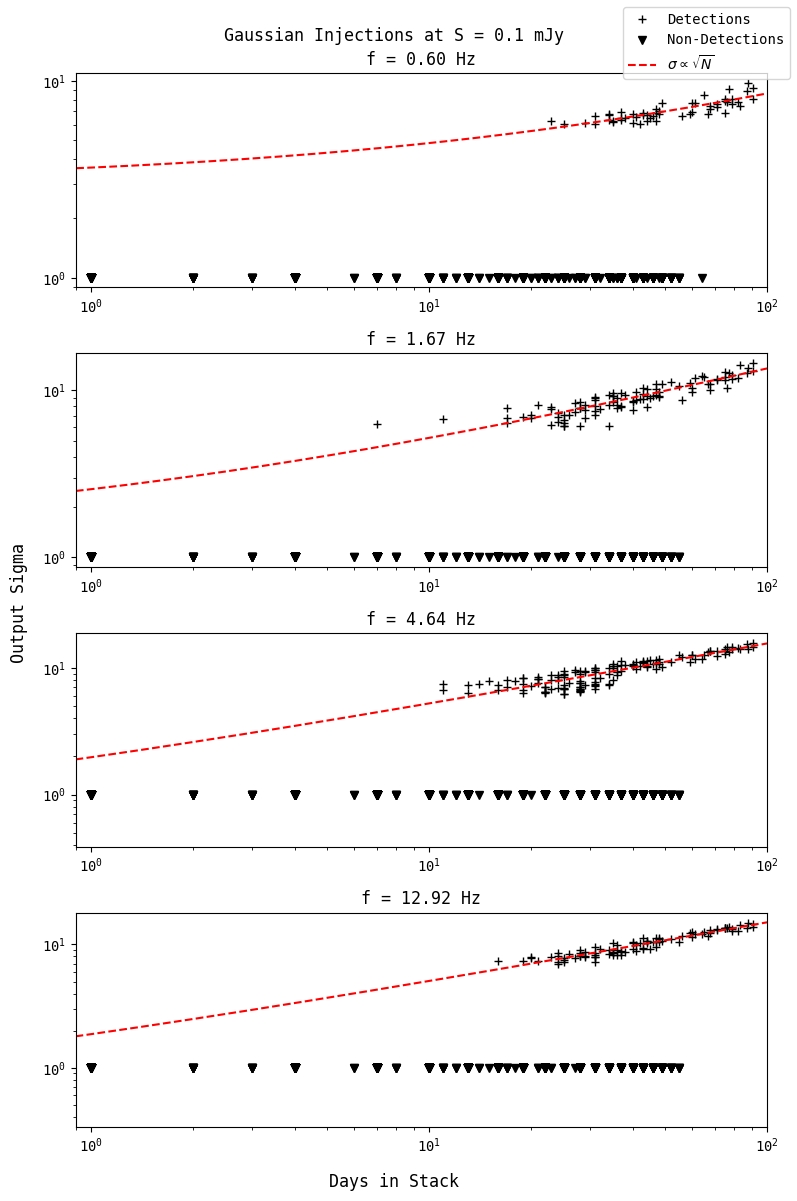

In [ ]:
const_inj = np.loadtxt('constant_01mJy_injections.txt')
# dec_mask = (const_inj[:, 1] > 70) & (const_inj[:, 1] < 80)
# ra_mask = (const_inj[:, 0] > 200) & (const_inj[:, 0] < 220)
# const_inj = const_inj[dec_mask & ra_mask]

f_unique = np.unique(const_inj[:, f_idx])[4:8]

fig, ax = plt.subplots(len(f_unique), 1, figsize = (8, 12))

for i in range(len(f_unique)):
    f_mask = const_inj[:, f_idx] == f_unique[i]
    outlier_mask = const_inj[:, output_sigma_idx] > 100.
    f_data = const_inj[f_mask & ~outlier_mask]
    found_mask = f_data[:, -1] > 0

    ax[i].plot(f_data[~found_mask, 2], np.ones(len(f_data[~found_mask])),
            'v', color = 'black')
    ax[i].plot(f_data[found_mask, 2], f_data[found_mask, output_sigma_idx],
            '+', color = 'black')
    ax[i].set_title(f'f = {f_unique[i]:.2f} Hz')

    N = f_data[found_mask, 2]
    sig = f_data[found_mask, output_sigma_idx]
    min_idx = np.argmin(sig)
    max_idx = np.argmax(sig)
    a_guess = (sig[max_idx] - sig[min_idx]) / (np.sqrt(N[max_idx]) - np.sqrt(N[min_idx]))
    B_guess = sig[min_idx] - a_guess * np.sqrt(N[min_idx])

    a, B = curve_fit(func_to_fit, 
                        f_data[found_mask, 2],
                        f_data[found_mask, output_sigma_idx],
                        p0 = [a_guess, B_guess]
                        )[0]

    ax[i].plot(np.linspace(0, 100, 1000), 
        a * np.sqrt(np.linspace(0, 100, 1000)) + B,
        'r--')
    ax[i].loglog()
    # ax[i].set_xlabel('Days in Stack')
    # ax[i].set_ylabel('Output Sigma')
    ax[i].set_xlim(0.9, 100)

ax[0].plot(-1, -1, '+', color = 'black', label = 'Detections')
ax[0].plot(-1, -1, 'v', color = 'black', label = 'Non-Detections')
ax[0].plot(-1, -1, 'r--', label = r'$\sigma \propto \sqrt{N}$')

fig.legend()
fig.supxlabel('Days in Stack')
fig.supylabel('Output Sigma')
fig.suptitle('Gaussian Injections at S = 0.1 mJy')
plt.tight_layout()

3. Injections with identical parameters save for flux appear to increase at a rate expected, but the sigmoid fit asymptotes earlier than perhaps we want.

Optimization terminated successfully.
         Current function value: 0.094156
         Iterations 9
S at P=0.5: 56.0976 ± 2.0399
Optimization terminated successfully.
         Current function value: 0.199735
         Iterations 8
S at P=0.5: 52.9627 ± 2.1043
Optimization terminated successfully.
         Current function value: 0.280954
         Iterations 7
S at P=0.5: 51.2492 ± 2.2670
Optimization terminated successfully.
         Current function value: 0.174855
         Iterations 8
S at P=0.5: 52.6552 ± 1.9720


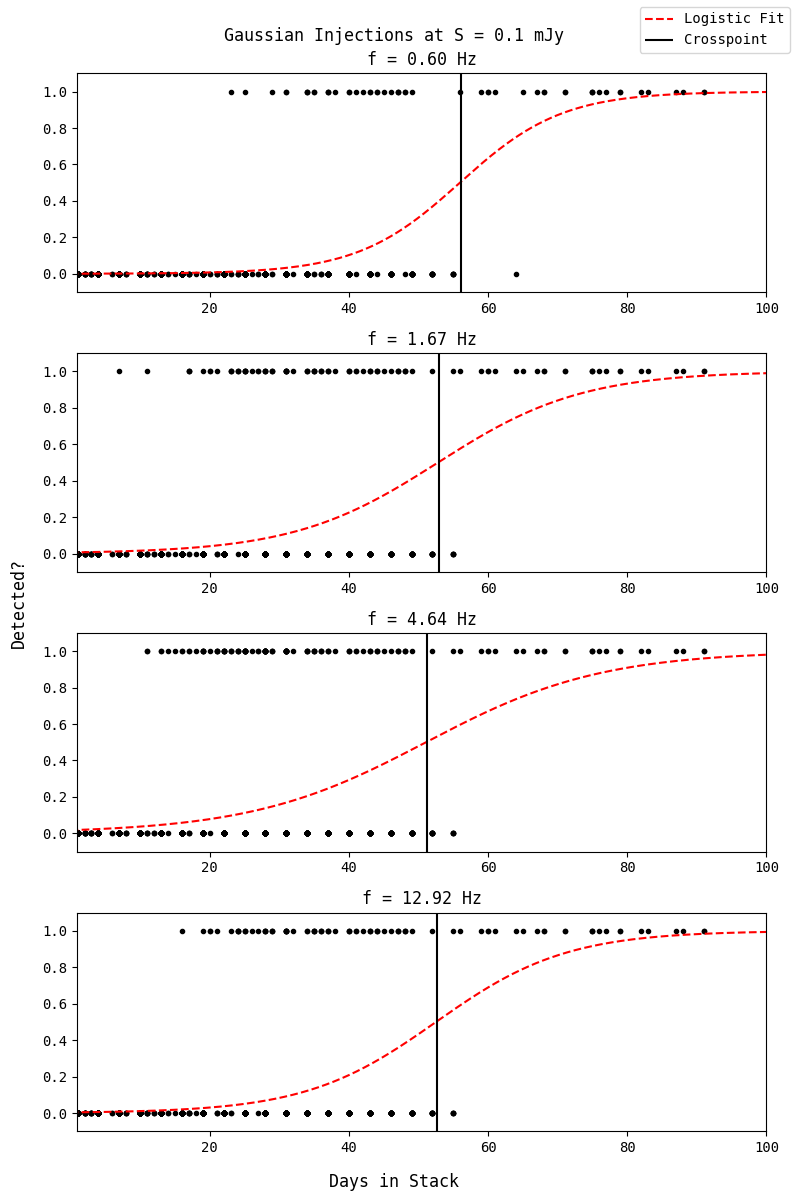

In [ ]:
fig, ax = plt.subplots(len(f_unique), 1, figsize = (8, 12))

for i in range(len(f_unique)):
    f_mask = const_inj[:, f_idx] == f_unique[i]
    outlier_mask = const_inj[:, output_sigma_idx] > 100.
    f_data = const_inj[f_mask & ~outlier_mask]
    found_mask = f_data[:, -1] > 0

    N = f_data[:, 2]
    y = found_mask.astype(int)

    N_cross, _, cdf_fit = get_cross_point(N, y, logspace = False)
    
    ax[i].plot(f_data[:, 2], y,
            '.', color = 'black')
    ax[i].set_title(f'f = {f_unique[i]:.2f} Hz')

    x = np.linspace(0, 100, 1000)
    ax[i].plot(x, 
        cdf_fit(x),
        'r--'
        )
    ax[i].vlines(N_cross,
                 ymin = -0.1,
                 ymax = 1.1,
                 color = 'black'
                 )
    ax[i].set_xlim(0.9, 100)
    ax[i].set_ylim(-0.1, 1.1)

ax[0].plot(-1, -1, 'r--', label = 'Logistic Fit')
ax[0].vlines(-1, 0.1, 0.2, color = 'black', label = 'Crosspoint')

fig.legend()
fig.supxlabel('Days in Stack')
fig.supylabel('Detected?')
fig.suptitle('Gaussian Injections at S = 0.1 mJy')
plt.tight_layout()